# PQDOS Metadata Scaling

Targeted measurements for the two `MetadataStore` relief changes
(see the [ADR-0006 amendment](../adr/0006-concurrency-contract.md)):

1. **`list()` JOIN** — one query instead of the old per-row N+1.
2. **Connection pool** — concurrent operations stop serializing on a single
   connection.

Unlike `01_performance.ipynb` (which measures whole `PUT`/`GET`/`REPAIR`
latency), these benchmarks drive `MetadataStore` directly, so they isolate the
metadata layer from crypto and HTTP transport.

Data is produced by `./scripts/run-metadata-benchmarks.sh`
(`metadata_list_sweep.csv`, `metadata_throughput.csv`).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

HERE = Path.cwd()


def load_csv(name):
    path = HERE / name
    if not path.exists():
        print(f"{name} not found — run ./scripts/run-metadata-benchmarks.sh")
        return None
    return pd.read_csv(path)


sweep = load_csv("metadata_list_sweep.csv")
tput = load_csv("metadata_throughput.csv")

## 1. list() scaling: one JOIN vs N+1 access

`list_ms` is a single `LEFT JOIN` returning every object with its shard
locations. `per_object_ms` fetches the same objects one-by-one — the per-row
access pattern the JOIN replaced. The gap widens with object count.

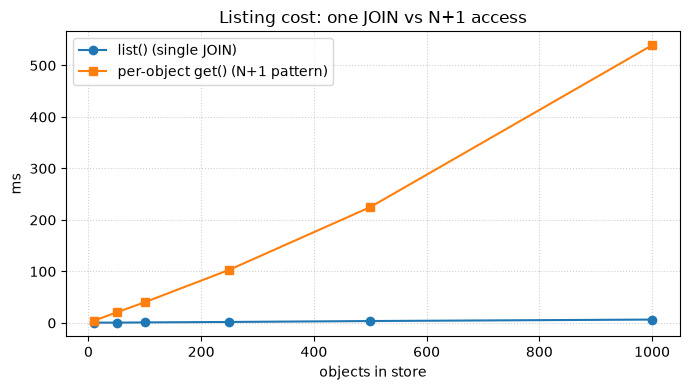

,num_objects,shards_per_object,list_ms,per_object_ms,speedup
0,10,6,0.646,4.467,6.9
1,50,6,0.637,20.527,32.2
2,100,6,1.049,40.263,38.4
3,250,6,1.932,103.264,53.4
4,500,6,3.722,224.940,60.4
5,1000,6,6.564,539.284,82.2


In [2]:
if sweep is None or sweep.empty:
    print("No list-sweep data.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(sweep["num_objects"], sweep["list_ms"],
            marker="o", label="list() (single JOIN)")
    ax.plot(sweep["num_objects"], sweep["per_object_ms"],
            marker="s", label="per-object get() (N+1 pattern)")
    ax.set_xlabel("objects in store")
    ax.set_ylabel("ms")
    ax.set_title("Listing cost: one JOIN vs N+1 access")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()
    display(sweep.assign(
        speedup=(sweep["per_object_ms"] / sweep["list_ms"]).round(1)).round(3))

## 2. Connection pool: concurrent throughput

Aggregate `get()` throughput as `pool_size` grows, one line per thread count.
`pool_size=1` reproduces the old single-connection serialization: adding threads
does not help. Larger pools let independent operations run in parallel.

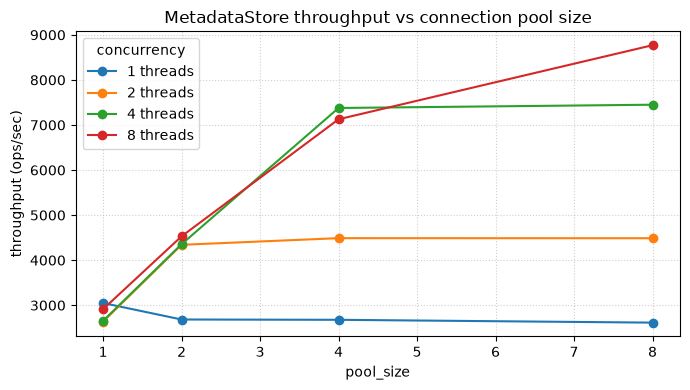

,pool_size,threads,throughput_ops_per_sec,speedup_vs_pool_min
3,1,8,2913.25,1.00
7,2,8,4529.69,1.55
11,4,8,7127.04,2.45
15,8,8,8770.36,3.01


In [3]:
if tput is None or tput.empty:
    print("No throughput data.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    for threads, grp in tput.groupby("threads"):
        grp = grp.sort_values("pool_size")
        ax.plot(grp["pool_size"], grp["throughput_ops_per_sec"],
                marker="o", label=f"{threads} threads")
    ax.set_xlabel("pool_size")
    ax.set_ylabel("throughput (ops/sec)")
    ax.set_title("MetadataStore throughput vs connection pool size")
    ax.legend(title="concurrency")
    ax.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Speedup from pooling at the highest concurrency: pool=max vs pool=1.
    max_threads = tput["threads"].max()
    hi = tput[tput["threads"] == max_threads].sort_values("pool_size")
    base = hi.iloc[0]["throughput_ops_per_sec"]
    hi = hi.assign(
        speedup_vs_pool_min=(hi["throughput_ops_per_sec"] / base).round(2))
    display(hi[["pool_size", "threads",
                "throughput_ops_per_sec", "speedup_vs_pool_min"]].round(2))